In [52]:
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

import re

In [53]:

import nltk

# تحميل الموارد المطلوبة مرة واحدة فقط
nltk.download('stopwords')   # الكلمات الشائعة
nltk.download('punkt')       # للتقطيع Tokenization
nltk.download('wordnet')     # لتصريف الكلمات Lemmatization



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/abdrabo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/abdrabo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/abdrabo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [54]:
df = pd.read_csv('data/Dataset-SA.csv')
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,super!,great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,positive
1,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,3,fair,the quality is good but the power of air is decent,positive
3,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,1,useless product,very bad product its a only a fan,negative
4,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,3,fair,ok ok product,neutral


In [55]:
data = df[['product_name','Review', 'Summary', 'Sentiment']]

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   product_name  205052 non-null  object
 1   Review        180388 non-null  object
 2   Summary       205041 non-null  object
 3   Sentiment     205052 non-null  object
dtypes: object(4)
memory usage: 6.3+ MB


In [57]:
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [58]:
data[data['Review'].isnull()]

,product_name,Review,Summary,Sentiment
41625,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",NaN,best product,positive
41626,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",NaN,very good,positive
41627,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",NaN,very comfortablegood qualitylove it,positive
41628,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",NaN,very soft and comfortable go for it,positive
41629,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",NaN,super product quality is vry good tnx flipkart,positive
...,...,...,...,...
113340,"Men 9325 Latest Collection Stylish Sports Sneakers Running Shoes Running Shoes For Men????(Red, Black)",NaN,ok oky hai according prise,positive
113341,"Men 9325 Latest Collection Stylish Sports Sneakers Running Shoes Running Shoes For Men????(Red, Black)",NaN,nice,positive
113342,"Men 9325 Latest Collection Stylish Sports Sneakers Running Shoes Running Shoes For Men????(Red, Black)",NaN,nice product,positive
113343,"Men 9325 Latest Collection Stylish Sports Sneakers Running Shoes Running Shoes For Men????(Red, Black)",NaN,nice,positive


In [59]:
#some times Review is Nan we replace it with empty str
data['Final Review'] = data['Review'].fillna('').astype(str) + " " + \
data['Summary'].fillna('').astype(str)

data['Final Review'] = data['Final Review'].str.lower()


/tmp/ipykernel_33094/3174985914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Final Review'] = data['Review'].fillna('').astype(str) + " " + \
/tmp/ipykernel_33094/3174985914.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Final Review'] = data['Final Review'].str.lower()


In [60]:
data.isnull().sum()

product_name        0
Review          24664
Summary            11
Sentiment           0
Final Review        0
dtype: int64

In [61]:
data = data[['product_name','Final Review', 'Sentiment']]

In [62]:
data['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [63]:
data.isnull().sum()

product_name    0
Final Review    0
Sentiment       0
dtype: int64

In [64]:
pd.set_option('display.max_rows', 10)        # Show all rows
pd.set_option('display.max_columns', None)     # Show all columns
pd.set_option('display.width', None)            # No limit for width
pd.set_option('display.max_colwidth', None)     # No limit for column content

In [65]:
data.head()

,product_name,Final Review,Sentiment
0,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",super! great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,positive
1,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",awesome best budget 2 fit cooler nice cooling,positive
2,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",fair the quality is good but the power of air is decent,positive
3,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",useless product very bad product its a only a fan,negative
4,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",fair ok ok product,neutral


In [66]:
data.to_csv('data/dataForSammary.csv', index=False, encoding='utf-8-sig')

In [67]:
data['Sentiment'].value_counts()

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

In [68]:
data=data[['Final Review', 'Sentiment']]

### imbalance data
i will undersample the data because if i stay the countvectorizer will disagree beacuase memory 

In [69]:
from sklearn.utils import shuffle

# Assuming your dataframe is 'data' and the sentiment column is 'Sentiment'

# Separate majority and minority classes
positive_data = data[data['Sentiment'] == 'positive']
negative_data = data[data['Sentiment'] == 'negative']

# Undersample the majority class (positive sentiment)
positive_data_undersampled = positive_data.sample(n=negative_data.shape[0], random_state=42)

# Combine the undersampled majority class with the minority class
data_balanced = pd.concat([positive_data_undersampled, negative_data])

# Shuffle the balanced dataset to mix the classes
data_balanced = shuffle(data_balanced, random_state=42)

# Display the new class distribution
print(data_balanced['Sentiment'].value_counts())


Sentiment
positive    28232
negative    28232
Name: count, dtype: int64


In [70]:
# الحصول على 10 أرقام عشوائية من الـ index
random_indices = np.random.choice(data.index, size=10, replace=False)

# اختيار الـ 10 عينات بناءً على الأرقام العشوائية
random_samples = data.loc[random_indices]
random_samples

,Final Review,Sentiment
130972,best in the market! it was good,positive
161600,just okay awesome,positive
122626,simply awesome nice product and value for money,positive
183650,don't waste your money very bad deliverynot good product,negative
132934,just wow! product is good and value for money installation is on time installation engineer is also good and showed polite attitude and perfectly installed the product,positive
147133,fabulous! this book is best for upsc aspirant,positive
3504,worthless dont buy this product during the call other ends voice is very low and on the top of flipkart will never support in rufunds this is geniune feedback after using the working product after few days for music listening this headphone has great voice output,neutral
50331,poor quality,negative
157078,just wow! awesome nd very comfortable,positive
143093,perfect product! the product is really awesome and easy to move,positive


In [71]:
def process_review(text):
    # Get English stopwords
    stopwords_english = stopwords.words('english')
    
    # Initialize the lemmatizer
    lemmatizer = WordNetLemmatizer()

    # Lowercase the text
    text = text.lower()

    # Remove punctuation, numbers, etc.
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize the text (split it into words)
    text_tokens = text.split()

    # Initialize a list to hold processed words
    texts_clean = []

    # Process each word
    for word in text_tokens:
        # Check if the word is not a stopword
        if word not in stopwords_english:
            # Lemmatize the word
            lemmatiz_word = lemmatizer.lemmatize(word)
            texts_clean.append(lemmatiz_word)

    # Join the processed words back into a string
    return ' '.join(texts_clean)

# Example usage
review = "This is an amazing product with great value for money!"
processed_review = process_review(review)
print(processed_review)

amazing product great value money


In [72]:
data['F_Review_cleaned'] = data['Final Review'].astype(str).apply(process_review)

In [73]:
#compare
data.head()

,Final Review,Sentiment,F_Review_cleaned
0,super! great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,positive,super great cooler excellent air flow price amazing unbelievablejust love
1,awesome best budget 2 fit cooler nice cooling,positive,awesome best budget fit cooler nice cooling
2,fair the quality is good but the power of air is decent,positive,fair quality good power air decent
3,useless product very bad product its a only a fan,negative,useless product bad product fan
4,fair ok ok product,neutral,fair ok ok product


In [74]:
data.drop('Final Review', axis=1, inplace=True)

In [75]:
data.shape

(205052, 2)

In [76]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming 'data_balanced' is your DataFrame with 'clean_text' and 'Sentiment'
X = data['F_Review_cleaned']
y = data['Sentiment']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create DataFrame for test data
test_data = pd.DataFrame({
    'review': X_test,
    'sentiment': y_test
})

# Save the test data to a CSV file
test_data.to_csv('data/sentiment_test_data.csv', index=False)

print("Test data saved to 'data/sentiment_test_data.csv'")


Test data saved to 'data/sentiment_test_data.csv'


In [77]:
X_train.shape, y_train.shape

((164041,), (164041,))

In [78]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer




vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # use unigrams and bigrams
    max_features=5000,   # limit the vocabulary size
    stop_words='english' # remove common English stop words
)

# Fit the vectorizer on the training data and transform it into numerical features
X_train = vectorizer.fit_transform(X_train)


# Step 4: Save the vectorizer
# Save the trained vectorizer to use it later on test data
joblib.dump(vectorizer, 'models/sentiment_tfidf_vectorizer.pkl')



['models/sentiment_tfidf_vectorizer.pkl']

In [79]:
y_train = y_train.map({"positive": 1, "negative": 0, "neutral": 2})
y_test  = y_test.map({"positive": 1, "negative": 0, "neutral": 2})

In [80]:
X_train.shape, y_train.shape

((164041, 5000), (164041,))

In [81]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)  # [0,1,2]
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
print(class_weights)


{np.int64(0): np.float64(2.4209835001033086), np.int64(1): np.float64(0.4103158642494097), np.int64(2): np.float64(6.6756602775403895)}


In [82]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    multi_class='multinomial',  # multi-class
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weights
)

# Train the model
lr_model.fit(X_train, y_train)

# حفظ الموديل
joblib.dump(lr_model, 'models/sentiment_logisticRegression_model.pkl')


/home/abdrabo/anaconda3/envs/nlp_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


['models/sentiment_logisticRegression_model.pkl']

In [83]:
from sklearn.metrics import accuracy_score
X_test_tfidf = vectorizer.transform(X_test)

# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy on Test Data:", accuracy)


Logistic Regression Accuracy on Test Data: 0.8755212016288313


In [84]:
# Classification report (includes precision, recall, f1-score for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'positive', 'neutral']))


Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.84      0.81      5646
    positive       0.98      0.89      0.93     33317
     neutral       0.31      0.70      0.43      2048

    accuracy                           0.88     41011
   macro avg       0.69      0.81      0.72     41011
weighted avg       0.92      0.88      0.89     41011



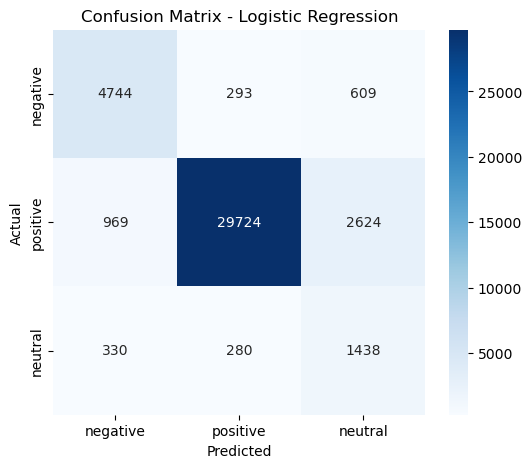

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive', 'neutral'],
            yticklabels=['negative', 'positive', 'neutral'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [86]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
joblib.dump(nb_model, 'models/sentiment_naiveBayes_model.pkl')


['models/sentiment_naiveBayes_model.pkl']

In [87]:
# Evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)
print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=['negative','positive','neutral']))

=== Naive Bayes ===
Accuracy: 0.9243861403038209
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82      5646
    positive       0.95      0.98      0.96     33317
     neutral       0.70      0.36      0.47      2048

    accuracy                           0.92     41011
   macro avg       0.82      0.72      0.75     41011
weighted avg       0.92      0.92      0.92     41011



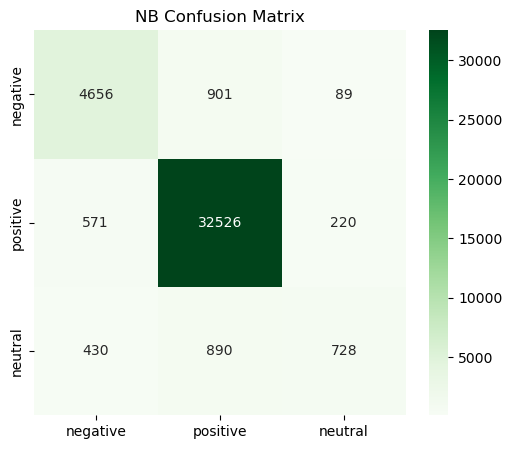

In [88]:

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative','positive','neutral'],
            yticklabels=['negative','positive','neutral'])
plt.title('NB Confusion Matrix')
plt.show()

In [89]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_dim = X_train.shape[1]  # عدد الخصائص من TF-IDF
num_classes = 3               # negative, positive, neutral

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # labels as integers
    metrics=['accuracy']
)

model.summary()


/home/abdrabo/anaconda3/envs/nlp_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,579 (2.47 MB)

 Trainable params: 648,579 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
!pip install tensorflow

In [91]:
history = model.fit(
    X_train, y_train,               # استخدم X_train و y_train اللي عندك
    validation_split=0.1,           # 10% من train للـ validation
    epochs=4,
    batch_size=64
)


Epoch 1/4
2307/2307 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.9235 - loss: 0.2354 - val_accuracy: 0.9287 - val_loss: 0.2155
Epoch 2/4
2307/2307 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9365 - loss: 0.1882 - val_accuracy: 0.9301 - val_loss: 0.2143
Epoch 3/4
2307/2307 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9432 - loss: 0.1688 - val_accuracy: 0.9316 - val_loss: 0.2235
Epoch 4/4
2307/2307 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.9494 - loss: 0.1508 - val_accuracy: 0.9315 - val_loss: 0.2329


In [92]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, class_names=['negative','positive','neutral']):
    """
    Evaluate a TensorFlow/Keras model on test data.
    
    Parameters:
    - model: Keras/TensorFlow model (already trained)
    - X_test: numpy array or matrix of test features
    - y_test: array-like of true labels
    - class_names: list of class names for report and confusion matrix
    """
    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.show()


In [93]:
model.save("models/nn_sentiment_model.h5")


  40/1282 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step 

2025-12-26 01:55:20.769796: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 820220000 exceeds 10% of free system memory.


1282/1282 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.85      0.84      5646
    positive       0.96      0.98      0.97     33317
     neutral       0.71      0.45      0.55      2048

    accuracy                           0.93     41011
   macro avg       0.83      0.76      0.79     41011
weighted avg       0.93      0.93      0.93     41011



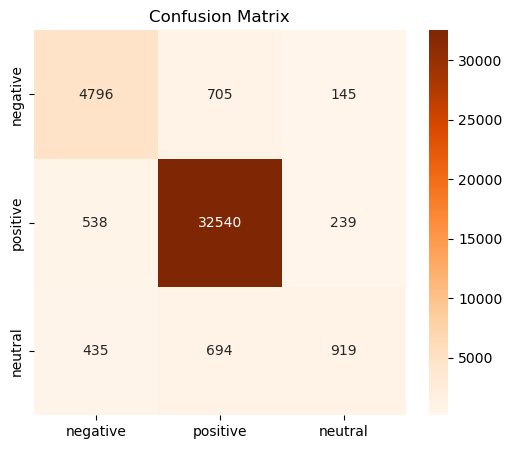

In [94]:
# تحويل X_test باستخدام الـ vectorizer اللي اتدرب على train data
X_test_np = vectorizer.transform(X_test).toarray().astype('float32')

# دلوقتي ممكن تمرره للـ function
evaluate_model(model, X_test_np, y_test)
